In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.absences import ExtracteurAbsences
from src.config import FIGURES, PREPARE
from src.donnees import decoupe
from src.evaluation import evalue
from src.graines import set_seed
from src.preparation import Preparateur
import src.modeles as M

set_seed()

X_app_brut, X_val_brut, y_app, y_val = decoupe()
extracteur = ExtracteurAbsences().fit(X_app_brut, y_app)

print(f"Données brutes d'apprentissage : {X_app_brut.shape}")
print(f"Premier groupe  : {len(extracteur.groupe1_)} colonnes")
print(f"Second groupe   : {len(extracteur.groupe2_)} colonnes")
print(f"Sous-blocs      : {len(extracteur.sous_blocs_)}")

T_CRITIQUE = stats.t.ppf(0.975, df=4)
print(f"\nSeuil de Student retenu, quatre degrés de liberté : {T_CRITIQUE:.3f}")

2026-08-25 03:58:37.558960: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-25 03:58:37.577624: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Données brutes d'apprentissage : (48000, 170)
Premier groupe  : 8 colonnes
Second groupe   : 56 colonnes
Sous-blocs      : 9

Seuil de Student retenu, quatre degrés de liberté : 2.776


In [2]:
def compare(reference, alternative, nom_ref, nom_alt, verbeux=True):
    """Paired comparison of two conditions evaluated on identical folds.

    Returns the mean difference, its standard error, and whether the
    difference is significant. A negative difference means the alternative
    costs less than the reference.
    """
    d = alternative["cout"].values - reference["cout"].values
    moyenne = d.mean()
    erreur = d.std(ddof=1) / np.sqrt(len(d))
    significatif = abs(moyenne) > T_CRITIQUE * erreur

    if verbeux:
        print(f"{nom_alt} moins {nom_ref}")
        print(f"  par partie : {np.round(d).astype(int)}")
        print(f"  écart moyen : {moyenne:+,.0f} ± {erreur:,.0f}")
        print(f"  {nom_alt} est meilleure sur {(d < 0).sum()} parties sur 5")
        print(f"  écart significatif : {'oui' if significatif else 'non'}\n")

    return {"ecart": moyenne, "erreur": erreur, "significatif": significatif}

In [3]:
def prepare_variante(nom: str) -> pd.DataFrame:
    """Build one preparation variant, fitted on the fitting split only."""
    X = X_app_brut.copy()

    if nom == "V0":
        # Reproduces common practice: drop heavily incomplete columns,
        # build nothing from the absence patterns.
        trop_vides = X.columns[X.isna().mean() > 0.10].tolist()
        X = X.drop(columns=trop_vides)
        groupe1_present = []
        non_normalisees = []
        print(f"V0 : {len(trop_vides)} colonnes supprimées")

    elif nom == "V1":
        X = extracteur.transform(X)
        groupe1_present = extracteur.groupe1_
        non_normalisees = ["profondeur_g1"] + extracteur.noms_indicatrices_

    elif nom == "V2":
        informatives = extracteur.groupe1_ + extracteur.groupe2_
        for colonne in informatives:
            X[f"absent_{colonne}"] = X[colonne].isna().astype(int)
        groupe1_present = extracteur.groupe1_
        non_normalisees = [f"absent_{c}" for c in informatives]
        print(f"V2 : {len(informatives)} indicatrices construites")

    else:
        raise ValueError(nom)

    prep = Preparateur(groupe1=groupe1_present,
                       non_normalisees=non_normalisees).fit(X)
    return prep.transform(X)


variantes = {nom: prepare_variante(nom) for nom in ["V0", "V1", "V2"]}

print()
for nom, X in variantes.items():
    print(f"{nom} : {X.shape[0]} lignes, {X.shape[1]} colonnes")

V0 : 28 colonnes supprimées
V2 : 64 indicatrices construites

V0 : 48000 lignes, 142 colonnes
V1 : 48000 lignes, 180 colonnes
V2 : 48000 lignes, 234 colonnes


In [4]:
# Vérification : les trois variantes portent bien sur les mêmes lignes
for nom, X in variantes.items():
    assert list(X.index) == list(X_app_brut.index), nom
    assert X.isna().sum().sum() == 0, nom

print("Les trois variantes portent sur les mêmes lignes, sans valeur manquante.")

# Quelles colonnes V0 supprime-t-elle
trop_vides = X_app_brut.columns[X_app_brut.isna().mean() > 0.10].tolist()
dans_g1 = [c for c in trop_vides if c in extracteur.groupe1_]
dans_g2 = [c for c in trop_vides if c in extracteur.groupe2_]

print(f"\nColonnes supprimées par V0 : {len(trop_vides)}")
print(f"  dont appartenant au premier groupe : {len(dans_g1)}")
print(f"  dont appartenant au second groupe  : {len(dans_g2)}")
print(f"  dont muettes                        : "
      f"{len(trop_vides) - len(dans_g1) - len(dans_g2)}")
print(f"\naa_000 conservée par V0 : {'aa_000' not in trop_vides}")

Les trois variantes portent sur les mêmes lignes, sans valeur manquante.

Colonnes supprimées par V0 : 28
  dont appartenant au premier groupe : 8
  dont appartenant au second groupe  : 16
  dont muettes                        : 4

aa_000 conservée par V0 : True


In [5]:
ablation = {}

for nom, X in variantes.items():
    t0 = time.time()
    ablation[nom] = evalue(lambda: M.foret_aleatoire(300), X, y_app, nom)
    r = ablation[nom]
    print(f"{nom} : coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   détection {r['rappel'].mean():.1%}"
          f"   pannes ratées {r['FN'].mean():.1f}"
          f"   ({time.time() - t0:.0f} s)")

V0 : coût    6,934 ±    895   détection 95.2%   pannes ratées 7.6   (155 s)
V1 : coût    6,714 ±    530   détection 96.4%   pannes ratées 5.8   (162 s)
V2 : coût    6,916 ±    906   détection 95.6%   pannes ratées 7.0   (147 s)


In [6]:
print("Comparaisons appariées\n")
resultats_ablation = {}
resultats_ablation["V1 contre V0"] = compare(ablation["V0"], ablation["V1"],
                                             "V0", "V1")
resultats_ablation["V2 contre V1"] = compare(ablation["V1"], ablation["V2"],
                                             "V1", "V2")
resultats_ablation["V2 contre V0"] = compare(ablation["V0"], ablation["V2"],
                                             "V0", "V2")

Comparaisons appariées

V1 moins V0
  par partie : [  320    30  -860   540 -1130]
  écart moyen : -220 ± 329
  V1 est meilleure sur 2 parties sur 5
  écart significatif : non

V2 moins V1
  par partie : [-690  540 -200  290 1070]
  écart moyen : +202 ± 303
  V2 est meilleure sur 2 parties sur 5
  écart significatif : non

V2 moins V0
  par partie : [ -370   570 -1060   830   -60]
  écart moyen : -18 ± 337
  V2 est meilleure sur 3 parties sur 5
  écart significatif : non



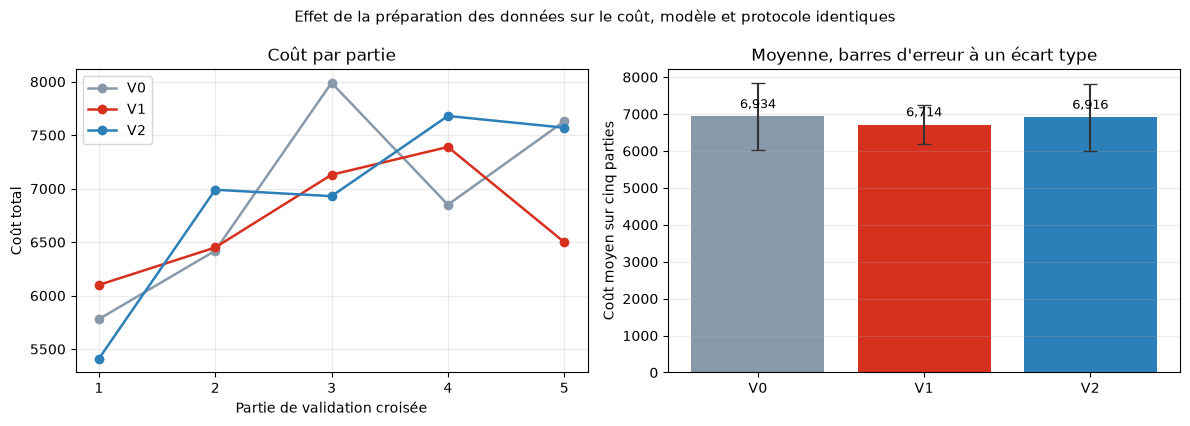

In [7]:
# Figure 1 : les trois variantes, partie par partie
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

parties = np.arange(1, 6)
couleurs = {"V0": "#8899aa", "V1": "#d7301f", "V2": "#2c7fb8"}

for nom in ["V0", "V1", "V2"]:
    axes[0].plot(parties, ablation[nom]["cout"], "o-",
                 color=couleurs[nom], label=nom, lw=1.8)
axes[0].set_xlabel("Partie de validation croisée")
axes[0].set_ylabel("Coût total")
axes[0].set_title("Coût par partie")
axes[0].set_xticks(parties)
axes[0].legend()
axes[0].grid(alpha=0.25)

moyennes = [ablation[n]["cout"].mean() for n in ["V0", "V1", "V2"]]
erreurs = [ablation[n]["cout"].std() for n in ["V0", "V1", "V2"]]
axes[1].bar(["V0", "V1", "V2"], moyennes, yerr=erreurs,
            color=[couleurs[n] for n in ["V0", "V1", "V2"]],
            error_kw={"ecolor": "#333333", "capsize": 5})
for i, m in enumerate(moyennes):
    axes[1].annotate(f"{m:,.0f}", (i, m), ha="center",
                     xytext=(0, 6), textcoords="offset points", fontsize=9)
axes[1].set_ylabel("Coût moyen sur cinq parties")
axes[1].set_title("Moyenne, barres d'erreur à un écart type")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Effet de la préparation des données sur le coût, "
             "modèle et protocole identiques", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "f8_ablation.png", dpi=150)
plt.show()

In [8]:
# Décomposition du coût entre les deux types d'erreur
detail = pd.DataFrame({
    nom: {
        "cout": r["cout"].mean(),
        "pannes_ratees": r["FN"].mean(),
        "fausses_alertes": r["FP"].mean(),
        "detection": r["rappel"].mean(),
        "fiabilite": r["precision"].mean(),
        "auc_pr": r["auc_pr"].mean(),
        "colonnes": variantes[nom].shape[1],
    }
    for nom, r in ablation.items()
}).T.round(4)

print(detail.to_string())
print("\nRappel : une panne ratée coûte 500 unités, une fausse alerte 10.")

      cout  pannes_ratees  fausses_alertes  detection  fiabilite  auc_pr  colonnes
V0  6934.0            7.6            313.4     0.9525     0.3300  0.8337     142.0
V1  6714.0            5.8            381.4     0.9637     0.2902  0.8283     180.0
V2  6916.0            7.0            341.6     0.9562     0.3109  0.8294     234.0

Rappel : une panne ratée coûte 500 unités, une fausse alerte 10.


In [9]:
X_V1 = variantes["V1"]
assert "aa_000" in X_V1.columns and "profondeur_g1" in X_V1.columns

conditions = {
    "usage + profondeur": X_V1,
    "usage seul":         X_V1.drop(columns=["profondeur_g1"]),
    "profondeur seule":   X_V1.drop(columns=["aa_000"]),
    "ni l'un ni l'autre": X_V1.drop(columns=["aa_000", "profondeur_g1"]),
}

for nom, X in conditions.items():
    print(f"{nom:<22} {X.shape[1]} colonnes")

usage + profondeur     180 colonnes
usage seul             179 colonnes
profondeur seule       179 colonnes
ni l'un ni l'autre     178 colonnes


In [10]:
factoriel = {"usage + profondeur": ablation["V1"]}   # déjà calculé

for nom, X in conditions.items():
    if nom in factoriel:
        continue
    t0 = time.time()
    factoriel[nom] = evalue(lambda: M.foret_aleatoire(300), X, y_app, nom)
    r = factoriel[nom]
    print(f"{nom:<22} coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   ({time.time() - t0:.0f} s)")

print()
tableau_2x2 = pd.DataFrame(
    [[factoriel["ni l'un ni l'autre"]["cout"].mean(),
      factoriel["profondeur seule"]["cout"].mean()],
     [factoriel["usage seul"]["cout"].mean(),
      factoriel["usage + profondeur"]["cout"].mean()]],
    index=["sans aa_000", "avec aa_000"],
    columns=["sans profondeur", "avec profondeur"],
).round(0)

print("Coût moyen selon les quatre conditions\n")
print(tableau_2x2.to_string())


usage seul             coût    6,778 ±    786   (163 s)
profondeur seule       coût    6,834 ±    805   (164 s)
ni l'un ni l'autre     coût    6,940 ±    681   (164 s)

Coût moyen selon les quatre conditions

             sans profondeur  avec profondeur
sans aa_000           6940.0           6834.0
avec aa_000           6778.0           6714.0


In [11]:
print("Apport de la variable de profondeur\n")

apport = {}
apport["avec aa_000"] = compare(factoriel["usage seul"],
                                factoriel["usage + profondeur"],
                                "usage seul", "usage + profondeur")
apport["sans aa_000"] = compare(factoriel["ni l'un ni l'autre"],
                                factoriel["profondeur seule"],
                                "ni l'un ni l'autre", "profondeur seule")

print("Apport de la variable d'usage\n")
apport_usage = compare(factoriel["ni l'un ni l'autre"],
                       factoriel["usage seul"],
                       "ni l'un ni l'autre", "usage seul")

Apport de la variable de profondeur

usage + profondeur moins usage seul
  par partie : [ 360  240 -340 -140 -440]
  écart moyen : -64 ± 157
  usage + profondeur est meilleure sur 3 parties sur 5
  écart significatif : non

profondeur seule moins ni l'un ni l'autre
  par partie : [ -10 -840  550 -790  560]
  écart moyen : -106 ± 307
  profondeur seule est meilleure sur 3 parties sur 5
  écart significatif : non

Apport de la variable d'usage

usage seul moins ni l'un ni l'autre
  par partie : [-720 -250  840 -540 -140]
  écart moyen : -162 ± 271
  usage seul est meilleure sur 4 parties sur 5
  écart significatif : non



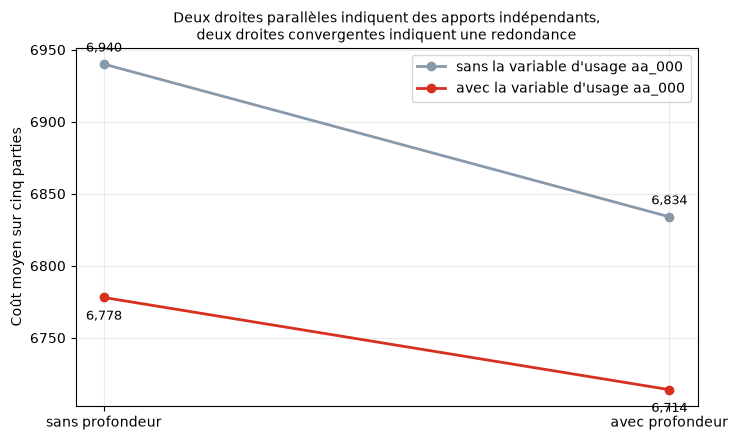


Apport de la profondeur en présence de aa_000 : -64
Apport de la profondeur en l'absence de aa_000 : -106
Différence des deux apports, dite interaction  : +42


In [12]:
# Figure 2 : le plan factoriel
fig, ax = plt.subplots(figsize=(7.5, 4.5))

positions = [0, 1]
sans_aa = [tableau_2x2.loc["sans aa_000", "sans profondeur"],
           tableau_2x2.loc["sans aa_000", "avec profondeur"]]
avec_aa = [tableau_2x2.loc["avec aa_000", "sans profondeur"],
           tableau_2x2.loc["avec aa_000", "avec profondeur"]]

ax.plot(positions, sans_aa, "o-", lw=2, color="#8899aa",
        label="sans la variable d'usage aa_000")
ax.plot(positions, avec_aa, "o-", lw=2, color="#d7301f",
        label="avec la variable d'usage aa_000")

for x, y in zip(positions, sans_aa):
    ax.annotate(f"{y:,.0f}", (x, y), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9)
for x, y in zip(positions, avec_aa):
    ax.annotate(f"{y:,.0f}", (x, y), xytext=(0, -16),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(positions)
ax.set_xticklabels(["sans profondeur", "avec profondeur"])
ax.set_ylabel("Coût moyen sur cinq parties")
ax.set_title("Deux droites parallèles indiquent des apports indépendants,\n"
             "deux droites convergentes indiquent une redondance", fontsize=10)
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES / "f9_plan_factoriel.png", dpi=150)
plt.show()

interaction = (apport["avec aa_000"]["ecart"] - apport["sans aa_000"]["ecart"])
print(f"\nApport de la profondeur en présence de aa_000 : "
      f"{apport['avec aa_000']['ecart']:+,.0f}")
print(f"Apport de la profondeur en l'absence de aa_000 : "
      f"{apport['sans aa_000']['ecart']:+,.0f}")
print(f"Différence des deux apports, dite interaction  : {interaction:+,.0f}")

In [13]:
synthese_exp = pd.DataFrame({
    nom: {
        "cout": r["cout"].mean(),
        "dispersion": r["cout"].std(),
        "detection": r["rappel"].mean(),
        "pannes_ratees": r["FN"].mean(),
        "fausses_alertes": r["FP"].mean(),
        "auc_pr": r["auc_pr"].mean(),
    }
    for nom, r in {**ablation, **factoriel}.items()
}).T.sort_values("cout").round(4)

synthese_exp.to_csv("../reports/experiences.csv")
print(synthese_exp.to_string())

                      cout  dispersion  detection  pannes_ratees  fausses_alertes  auc_pr
V1                  6714.0    529.7452     0.9637            5.8            381.4  0.8283
usage + profondeur  6714.0    529.7452     0.9637            5.8            381.4  0.8283
usage seul          6778.0    785.9198     0.9575            6.8            337.8  0.8246
profondeur seule    6834.0    804.5993     0.9575            6.8            343.4  0.8273
V2                  6916.0    906.2450     0.9562            7.0            341.6  0.8294
V0                  6934.0    894.7793     0.9525            7.6            313.4  0.8337
ni l'un ni l'autre  6940.0    680.6982     0.9600            6.4            374.0  0.8282


In [14]:
# Récapitulatif des comparaisons appariées
lignes = []
for nom, res in resultats_ablation.items():
    lignes.append({"comparaison": nom, "ecart": round(res["ecart"]),
                   "erreur": round(res["erreur"]),
                   "significatif": "oui" if res["significatif"] else "non"})
for nom, res in apport.items():
    lignes.append({"comparaison": f"apport profondeur, {nom}",
                   "ecart": round(res["ecart"]), "erreur": round(res["erreur"]),
                   "significatif": "oui" if res["significatif"] else "non"})
lignes.append({"comparaison": "apport usage aa_000",
               "ecart": round(apport_usage["ecart"]),
               "erreur": round(apport_usage["erreur"]),
               "significatif": "oui" if apport_usage["significatif"] else "non"})

recap = pd.DataFrame(lignes)
recap.to_csv("../reports/comparaisons_appariees.csv", index=False)
print(recap.to_string(index=False))
print("\nUn écart négatif signifie que la condition ajoutée réduit le coût.")

                   comparaison  ecart  erreur significatif
                  V1 contre V0   -220     329          non
                  V2 contre V1    202     303          non
                  V2 contre V0    -18     337          non
apport profondeur, avec aa_000    -64     157          non
apport profondeur, sans aa_000   -106     307          non
           apport usage aa_000   -162     271          non

Un écart négatif signifie que la condition ajoutée réduit le coût.


In [15]:
# Position des variantes par rapport au banc d'essai
banc = pd.read_csv("../reports/benchmark.csv", index_col=0)

print("Repères\n")
print(f"  règle naïve sur une partie              : {80000:>8,}")
print(f"  meilleur modèle du banc d'essai         : "
      f"{banc['cout'].min():>8,.0f}")
print(f"  meilleure variante de cette expérience  : "
      f"{synthese_exp['cout'].min():>8,.0f}")
print("\nLa forêt aléatoire employée ici est celle du banc d'essai, sans")
print("modification de ses paramètres. L'écart observé entre variantes est")
print("donc entièrement imputable à la préparation des données.")

Repères

  règle naïve sur une partie              :   80,000
  meilleur modèle du banc d'essai         :    6,576
  meilleure variante de cette expérience  :    6,714

La forêt aléatoire employée ici est celle du banc d'essai, sans
modification de ses paramètres. L'écart observé entre variantes est
donc entièrement imputable à la préparation des données.


In [ ]:
def compare_mesure(reference, alternative, mesure, nom_ref, nom_alt):
    """Paired comparison on any recorded measure, not only cost."""
    d = alternative[mesure].values - reference[mesure].values
    moyenne = d.mean()
    erreur = d.std(ddof=1) / np.sqrt(len(d))
    print(f"{mesure:<10} {nom_alt} moins {nom_ref} : "
          f"{moyenne:+8.2f} ± {erreur:6.2f}   "
          f"{'significatif' if abs(moyenne) > T_CRITIQUE * erreur else 'non significatif'}")
    print(f"           par partie : {np.round(d, 2)}")


for mesure in ["FN", "FP", "rappel", "auc_pr"]:
    compare_mesure(ablation["V0"], ablation["V1"], mesure, "V0", "V1")
print()
for mesure in ["FN", "FP", "rappel", "auc_pr"]:
    compare_mesure(ablation["V1"], ablation["V2"], mesure, "V1", "V2")